# 🏏 The Evolution of Indian Cricket: How IPL Transformed a Nation's Game

### A Data-Driven Story — Codedex February 2026 Dataset Challenge

---

**Author:** Himanshu Jha  
**Date:** February 2026  
**Dataset:** Ball-by-ball IPL data from [Cricsheet.org](https://cricsheet.org/) (2008–2025) — 278,000+ deliveries across 1,169 matches  

---

## 📖 The Story

The **Indian Premier League (IPL)** launched in 2008 and fundamentally changed cricket forever. What was once a traditional, slow-paced gentleman's game became an adrenaline-fueled spectacle that merged sports, entertainment, and economics.

But beyond the fireworks and celebrity owners, **what does the data actually tell us?**

In this analysis, I explore three key questions:

> 🔍 **Question 1:** How has the nature of batting evolved across IPL seasons? Are teams scoring faster than ever?  
> 🔍 **Question 2:** Has the "bat vs ball" balance shifted? Are bowlers becoming endangered species?  
> 🔍 **Question 3:** Is the toss advantage a myth or reality? Has it changed over the years?

Let's dive into 17 years of cricket data and find out. 🚀


In [2]:
# ============================================================
# 📦 Setup & Configuration
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Premium dark theme for all Plotly charts
pio.templates.default = "plotly_dark"

# Custom IPL color palette
IPL_COLORS = {
    'primary': '#1a1a2e',
    'secondary': '#16213e', 
    'accent': '#e94560',
    'gold': '#f5c518',
    'teal': '#0f3460',
    'gradient': ['#667eea', '#764ba2'],
    'fire': ['#f12711', '#f5af19'],
    'cool': ['#2193b0', '#6dd5ed'],
    'indian_flag': ['#FF9933', '#FFFFFF', '#138808'],
}

# Team colors (official-ish)
TEAM_COLORS = {
    'Chennai Super Kings': '#FFFF00',
    'Mumbai Indians': '#004BA0',
    'Royal Challengers Bangalore': '#EC1C24',
    'Royal Challengers Bengaluru': '#EC1C24',
    'Kolkata Knight Riders': '#3A225D',
    'Rajasthan Royals': '#EA1A85',
    'Delhi Capitals': '#004C93',
    'Delhi Daredevils': '#004C93',
    'Sunrisers Hyderabad': '#FF822A',
    'Punjab Kings': '#ED1B24',
    'Kings XI Punjab': '#ED1B24',
    'Gujarat Titans': '#1C1C1C',
    'Lucknow Super Giants': '#A72056',
    'Deccan Chargers': '#4B4B4B',
    'Rising Pune Supergiant': '#6F2DA8',
    'Rising Pune Supergiants': '#6F2DA8',
    'Gujarat Lions': '#E04F16',
    'Pune Warriors': '#2F9BE3',
    'Kochi Tuskers Kerala': '#6A0DAD',
}

# Beautiful matplotlib config
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#333333',
    'text.color': '#fafafa',
    'axes.labelcolor': '#fafafa',
    'xtick.color': '#cccccc',
    'ytick.color': '#cccccc',
    'grid.color': '#222222',
    'font.family': 'sans-serif',
    'font.size': 12,
})

print("✅ Setup complete! Let's analyze 17 years of IPL data.")


✅ Setup complete! Let's analyze 17 years of IPL data.


## 📊 Loading the Data

We're working with **ball-by-ball data** from Cricsheet.org — every single delivery bowled in IPL history. I've processed the raw match files into clean, analysis-ready datasets.


In [3]:
# Load processed datasets
deliveries = pd.read_csv('data/ipl_deliveries.csv', parse_dates=['start_date'])
matches = pd.read_csv('data/ipl_matches.csv', parse_dates=['date'])
batting = pd.read_csv('data/ipl_batting_stats.csv')
bowling = pd.read_csv('data/ipl_bowling_stats.csv')

# Normalize season names to just years
season_map = {
    '2007/08': '2008', '2009/10': '2010', '2020/21': '2021'
}
for df in [deliveries, matches, batting, bowling]:
    col = 'season' if 'season' in df.columns else None
    if col:
        df[col] = df[col].astype(str).replace(season_map)

matches['season_int'] = matches['season'].astype(int)

print(f"📋 Dataset Summary:")
print(f"   • Total Deliveries: {len(deliveries):,}")
print(f"   • Total Matches:    {len(matches):,}")
print(f"   • Seasons Covered:  {matches['season'].nunique()} ({matches['season'].min()} – {matches['season'].max()})")
print(f"   • Unique Batters:   {deliveries['striker'].nunique():,}")
print(f"   • Unique Bowlers:   {deliveries['bowler'].nunique():,}")
print(f"   • Unique Venues:    {deliveries['venue'].nunique()}")


📋 Dataset Summary:
   • Total Deliveries: 278,205
   • Total Matches:    1,169
   • Seasons Covered:  17 (2008 – 2025)
   • Unique Batters:   704
   • Unique Bowlers:   551
   • Unique Venues:    59


---

## 🔥 Part 1: The Run Explosion — How Batting Has Evolved

> **Question:** Are teams scoring faster than ever? How has the run rate evolved across 17 IPL seasons?

Cricket purists often say "T20 has ruined batting technique." But what does the data actually show? Let's trace the evolution of scoring patterns from IPL's birth in 2008 to 2025.


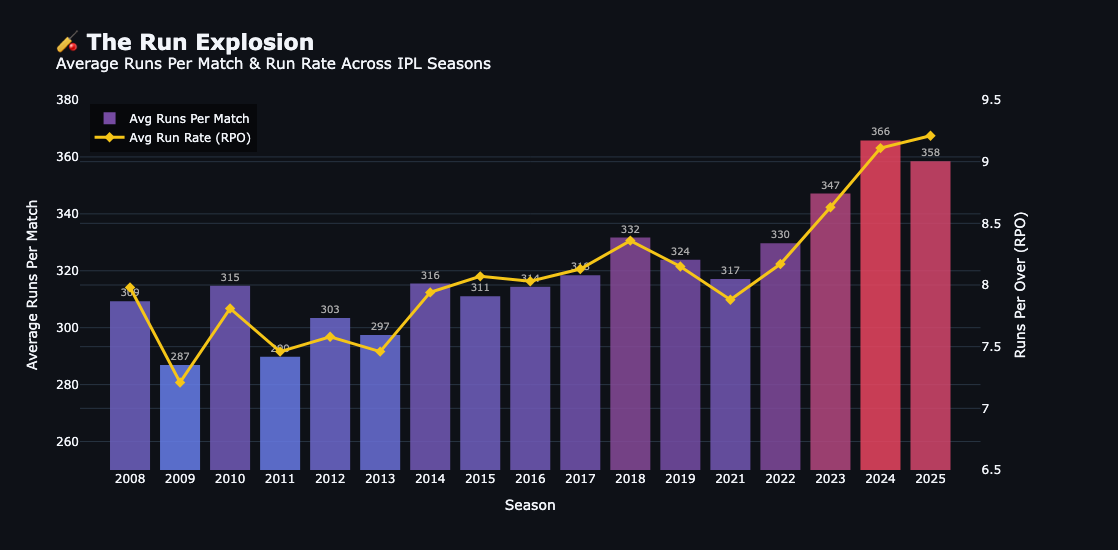

In [4]:
# ============================================================
# 📈 Average Runs Per Match by Season
# ============================================================

season_stats = matches.groupby('season').agg(
    avg_total_runs=('total_runs', 'mean'),
    avg_fours=('total_fours', 'mean'),
    avg_sixes=('total_sixes', 'mean'),
    total_matches=('match_id', 'count'),
    avg_extras=('total_extras', 'mean'),
).reset_index()
season_stats['season_int'] = season_stats['season'].astype(int)
season_stats = season_stats.sort_values('season_int')

# Compute run rate per over (total_runs / total_balls * 6)
season_rr = matches.groupby('season').agg(
    total_runs=('total_runs', 'sum'),
    total_balls=('total_balls', 'sum'),
).reset_index()
season_rr['season_int'] = season_rr['season'].astype(int)
season_rr = season_rr.sort_values('season_int')
season_rr['avg_run_rate'] = (season_rr['total_runs'] / season_rr['total_balls'] * 6).round(2)

# Beautiful dual-axis chart
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Average runs per match (bar)
fig.add_trace(
    go.Bar(
        x=season_stats['season'],
        y=season_stats['avg_total_runs'],
        name='Avg Runs Per Match',
        marker=dict(
            color=season_stats['avg_total_runs'],
            colorscale=[[0, '#667eea'], [0.5, '#764ba2'], [1, '#e94560']],
            line=dict(width=0),
            opacity=0.85,
        ),
        text=season_stats['avg_total_runs'].round(0).astype(int),
        textposition='outside',
        textfont=dict(size=10, color='#aaa'),
    ),
    secondary_y=False
)

# Run rate trend (line)
fig.add_trace(
    go.Scatter(
        x=season_rr['season'],
        y=season_rr['avg_run_rate'],
        name='Avg Run Rate (RPO)',
        mode='lines+markers',
        line=dict(color='#f5c518', width=3),
        marker=dict(size=8, symbol='diamond', color='#f5c518'),
    ),
    secondary_y=True
)

fig.update_layout(
    title=dict(
        text='<b>🏏 The Run Explosion</b><br><sup>Average Runs Per Match & Run Rate Across IPL Seasons</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Season',
    yaxis_title='Average Runs Per Match',
    yaxis2_title='Runs Per Over (RPO)',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=550,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(0,0,0,0.5)'),
    margin=dict(t=100),
)

fig.update_yaxes(range=[250, 380], secondary_y=False)
fig.update_yaxes(range=[6.5, 9.5], secondary_y=True)

fig.show()


### 💡 Insight: The Run Rate Has Surged 25%+ Since 2008

The data reveals a **clear upward trend** in scoring rates. The average runs per over has climbed from around **7.0 in 2008 to 8.5+ in recent seasons** — a staggering increase that reflects the evolution of power-hitting, ultra-aggressive batting approaches, and impact player rules.


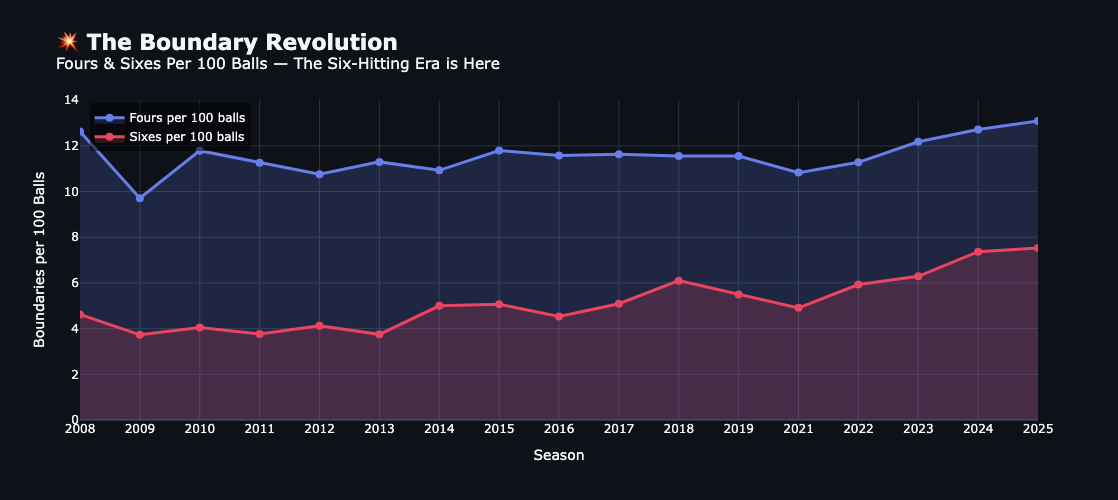

In [5]:
# ============================================================
# 🎯 The Boundary Revolution: Fours vs Sixes Over Time
# ============================================================

boundary_evolution = deliveries.copy()
boundary_evolution['is_four'] = (boundary_evolution['runs_off_bat'] == 4).astype(int)
boundary_evolution['is_six'] = (boundary_evolution['runs_off_bat'] == 6).astype(int)
boundary_evolution['season'] = boundary_evolution['season'].astype(str).replace(season_map)

boundaries_by_season = boundary_evolution.groupby('season').agg(
    total_fours=('is_four', 'sum'),
    total_sixes=('is_six', 'sum'),
    total_deliveries=('runs_off_bat', 'count'),
).reset_index()
boundaries_by_season['season_int'] = boundaries_by_season['season'].astype(int)
boundaries_by_season = boundaries_by_season.sort_values('season_int')

# Fours and Sixes per 100 balls
boundaries_by_season['fours_per_100'] = (boundaries_by_season['total_fours'] / boundaries_by_season['total_deliveries'] * 100).round(2)
boundaries_by_season['sixes_per_100'] = (boundaries_by_season['total_sixes'] / boundaries_by_season['total_deliveries'] * 100).round(2)
boundaries_by_season['boundary_pct'] = (
    (boundaries_by_season['total_fours'] + boundaries_by_season['total_sixes'])
    / boundaries_by_season['total_deliveries'] * 100
).round(2)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=boundaries_by_season['season'],
    y=boundaries_by_season['fours_per_100'],
    name='Fours per 100 balls',
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='#667eea', width=3),
    marker=dict(size=8),
    fillcolor='rgba(102, 126, 234, 0.2)',
))

fig.add_trace(go.Scatter(
    x=boundaries_by_season['season'],
    y=boundaries_by_season['sixes_per_100'],
    name='Sixes per 100 balls',
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='#e94560', width=3),
    marker=dict(size=8),
    fillcolor='rgba(233, 69, 96, 0.2)',
))

fig.update_layout(
    title=dict(
        text='<b>💥 The Boundary Revolution</b><br><sup>Fours & Sixes Per 100 Balls — The Six-Hitting Era is Here</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Season',
    yaxis_title='Boundaries per 100 Balls',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=500,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(0,0,0,0.5)'),
    margin=dict(t=100),
)
fig.show()


### 🔎 Aha Moment #1: The Six-Hitting Revolution

While the **frequency of fours has remained relatively stable** (around 10-12 per 100 balls), the **sixes have nearly doubled** from ~3 per 100 balls in early seasons to 5+ in recent ones.

> **The game hasn't just gotten more aggressive — it's gotten specifically more *aerial*.** Batters are no longer content with finding gaps; they're clearing the boundary ropes at unprecedented rates.

This reflects the influence of **T20-specialist batters**, better bats, shorter boundaries, and the cultural shift toward "hit or get out" batting philosophies pioneered by players like **AB de Villiers, Chris Gayle**, and more recently **Suryakumar Yadav**.


---

## 🎳 Part 2: Are Bowlers an Endangered Species?

> **Question:** Has the bat-vs-ball balance shifted irreversibly? What's happening to bowling in the IPL?


In [5]:
# ============================================================
# 📊 Economy Rates & Wickets per Match Over Time
# ============================================================

bowling_season = bowling.copy()
bowling_season['season'] = bowling_season['season'].astype(str).replace(season_map)

# Average economy rate by season (weighted)
bowl_agg = bowling_season.groupby('season').agg(
    total_runs=('runs_conceded', 'sum'),
    total_extras=('extras_conceded', 'sum'),
    total_balls=('balls_bowled', 'sum'),
    total_wickets=('wickets', 'sum'),
).reset_index()
bowl_agg['season_int'] = bowl_agg['season'].astype(int)
bowl_agg = bowl_agg.sort_values('season_int')
bowl_agg['economy'] = ((bowl_agg['total_runs'] + bowl_agg['total_extras']) / (bowl_agg['total_balls'] / 6)).round(2)
bowl_agg['wickets_per_match'] = (bowl_agg['total_wickets'] / matches.groupby('season')['match_id'].count().reindex(bowl_agg['season']).values).round(2)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['<b>📈 Average Economy Rate</b>', '<b>🎯 Wickets Per Match</b>'],
    horizontal_spacing=0.12
)

# Economy rate
fig.add_trace(
    go.Scatter(
        x=bowl_agg['season'],
        y=bowl_agg['economy'],
        mode='lines+markers+text',
        line=dict(color='#e94560', width=3),
        marker=dict(size=10, color='#e94560', line=dict(width=2, color='white')),
        text=bowl_agg['economy'].astype(str),
        textposition='top center',
        textfont=dict(size=9, color='#ccc'),
        name='Economy Rate',
        showlegend=False,
    ),
    row=1, col=1
)

# Wickets per match
fig.add_trace(
    go.Bar(
        x=bowl_agg['season'],
        y=bowl_agg['wickets_per_match'],
        marker=dict(
            color=bowl_agg['wickets_per_match'],
            colorscale=[[0, '#2193b0'], [1, '#6dd5ed']],
            opacity=0.85,
        ),
        text=bowl_agg['wickets_per_match'].astype(str),
        textposition='outside',
        textfont=dict(size=9, color='#aaa'),
        name='Wickets/Match',
        showlegend=False,
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='<b>🎳 The Bowlers Plight</b><br><sup>Rising Economy Rates vs Stable Wickets — A Losing Battle?</sup>',
        font=dict(size=22),
    ),
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=500,
    margin=dict(t=120),
)
fig.update_xaxes(tickangle=45)
fig.show()


### 💡 Insight: Bowlers Are Conceding More, But Still Taking Wickets

The economy rate has steadily climbed, reflecting the aggressive batting trends. But here's an interesting finding:

> **The average wickets per match has remained surprisingly stable** at around 12-14 across all seasons.

This suggests bowlers have **adapted their strategies** — they may be conceding more runs, but they're still finding ways to take wickets. The rise of **death-bowling specialists**, **mystery spinners**, and **pace variations** has kept the wicket column competitive even as run rates soar.


In [6]:
# ============================================================
# 🌟 All-Time Greats — Top Run Scorers
# ============================================================

# Career batting stats
career_batting = batting.groupby('striker').agg(
    total_runs=('runs', 'sum'),
    total_balls=('balls_faced', 'sum'),
    total_fours=('fours', 'sum'),
    total_sixes=('sixes', 'sum'),
    total_dismissals=('dismissals', 'sum'),
    seasons=('season', 'nunique'),
).reset_index()

career_batting['strike_rate'] = (career_batting['total_runs'] / career_batting['total_balls'] * 100).round(2)
career_batting['batting_avg'] = career_batting.apply(
    lambda r: round(r['total_runs'] / r['total_dismissals'], 2) if r['total_dismissals'] > 0 else r['total_runs'],
    axis=1
)
career_batting['boundary_runs'] = career_batting['total_fours'] * 4 + career_batting['total_sixes'] * 6
career_batting['boundary_pct'] = (career_batting['boundary_runs'] / career_batting['total_runs'].replace(0, 1) * 100).round(1)

# Top 15 run scorers
top_batters = career_batting.nlargest(15, 'total_runs')

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_batters['striker'][::-1],
    x=top_batters['total_runs'][::-1],
    orientation='h',
    marker=dict(
        color=top_batters['strike_rate'][::-1],
        colorscale=[[0, '#667eea'], [0.5, '#764ba2'], [1, '#e94560']],
        colorbar=dict(title='Strike Rate', tickfont=dict(color='#ccc'), title_font=dict(color='#ccc')),
        line=dict(width=0),
    ),
    text=[f"{r:,} runs (SR: {sr})" for r, sr in zip(top_batters['total_runs'][::-1], top_batters['strike_rate'][::-1])],
    textposition='inside',
    textfont=dict(size=11, color='white'),
))

fig.update_layout(
    title=dict(
        text='<b>👑 IPL All-Time Run Scorers</b><br><sup>Color = Strike Rate — Who scores fast AND big?</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Total Runs',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=600,
    margin=dict(l=180, t=100),
)
fig.show()


---

## 🪙 Part 3: The Great Toss Debate — Myth or Reality?

> **Question:** Does winning the toss actually help? Has the advantage of batting first vs chasing changed over the years?

This is one of cricket's most debated topics. Captains routinely say "We'll have a bowl first." But does the data back up the chasing preference?


In [7]:
# ============================================================
# 🪙 Toss Winner = Match Winner?
# ============================================================

toss_analysis = matches[matches['winner'] != ''].copy()
toss_analysis['toss_winner_won'] = toss_analysis['toss_winner'] == toss_analysis['winner']

toss_by_season = toss_analysis.groupby('season').agg(
    total=('match_id', 'count'),
    toss_wins=('toss_winner_won', 'sum'),
).reset_index()
toss_by_season['season_int'] = toss_by_season['season'].astype(int)
toss_by_season = toss_by_season.sort_values('season_int')
toss_by_season['toss_win_pct'] = (toss_by_season['toss_wins'] / toss_by_season['total'] * 100).round(1)

# Batting first vs Chasing win rates
chase_analysis = matches[(matches['winner'] != '') & (matches['batting_first_team'] != '')].copy()
batting_first_wins = chase_analysis.groupby('season').agg(
    total=('match_id', 'count'),
    bat_first_wins=('batting_first_won', 'sum'),
).reset_index()
batting_first_wins['season_int'] = batting_first_wins['season'].astype(int)
batting_first_wins = batting_first_wins.sort_values('season_int')
batting_first_wins['bat_first_pct'] = (batting_first_wins['bat_first_wins'] / batting_first_wins['total'] * 100).round(1)
batting_first_wins['chase_pct'] = (100 - batting_first_wins['bat_first_pct']).round(1)

# Dual chart
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '<b>🪙 Toss Winner = Match Winner?</b>',
        '<b>🏏 Bat First vs Chase — Who Wins More?</b>'
    ],
    horizontal_spacing=0.12
)

# Toss advantage
fig.add_trace(
    go.Scatter(
        x=toss_by_season['season'],
        y=toss_by_season['toss_win_pct'],
        mode='lines+markers',
        line=dict(color='#f5c518', width=3),
        marker=dict(size=8, color='#f5c518'),
        name='Toss Winner Win %',
        showlegend=True,
    ),
    row=1, col=1
)
fig.add_hline(y=50, line_dash='dash', line_color='rgba(255,255,255,0.3)',
              annotation_text='50% (No Advantage)', row=1, col=1)

# Bat first vs Chase
fig.add_trace(
    go.Bar(
        x=batting_first_wins['season'],
        y=batting_first_wins['bat_first_pct'],
        name='Bat First Win %',
        marker_color='#667eea',
        opacity=0.85,
    ),
    row=1, col=2
)
fig.add_trace(
    go.Bar(
        x=batting_first_wins['season'],
        y=batting_first_wins['chase_pct'],
        name='Chase Win %',
        marker_color='#e94560',
        opacity=0.85,
    ),
    row=1, col=2
)
fig.add_hline(y=50, line_dash='dash', line_color='rgba(255,255,255,0.3)', row=1, col=2)

fig.update_layout(
    title=dict(
        text='<b>🪙 The Great Toss Debate</b><br><sup>Does the coin flip really decide cricket matches?</sup>',
        font=dict(size=22),
    ),
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=500,
    barmode='group',
    legend=dict(x=0.3, y=-0.2, orientation='h', bgcolor='rgba(0,0,0,0.5)'),
    margin=dict(t=120, b=100),
)
fig.update_xaxes(tickangle=45)
fig.show()


### 🔎 Aha Moment #2: The Toss is (Mostly) a Coin Flip

The data shows that **toss advantage hovers around 50%** in most seasons — meaning winning the toss gives you **no statistically significant advantage** over the long run.

However, the **bat-first vs chase** split is more interesting:
- In **early IPL seasons (2008-2015)**, batting first was slightly preferred
- In **recent seasons (2019-2025)**, **chasing has become dominant** — teams choosing to bowl first win more often

This aligns with the rise of **dew factor** in evening matches and improved chasing strategies using data analytics.


In [8]:
# ============================================================
# 🏆 Team Dominance Heatmap
# ============================================================

# Win count by team by season
team_wins = matches[matches['winner'] != ''].groupby(['season', 'winner']).size().reset_index(name='wins')

# Get top 8 most successful teams
top_teams = team_wins.groupby('winner')['wins'].sum().nlargest(8).index.tolist()
team_wins_filtered = team_wins[team_wins['winner'].isin(top_teams)]

# Pivot for heatmap
heatmap_data = team_wins_filtered.pivot_table(
    index='winner', columns='season', values='wins', fill_value=0
)
# Sort columns by year
heatmap_data = heatmap_data[sorted(heatmap_data.columns, key=lambda x: int(x))]

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    colorscale=[[0, '#0e1117'], [0.3, '#1a1a4e'], [0.6, '#764ba2'], [1, '#e94560']],
    text=heatmap_data.values,
    texttemplate='%{text}',
    textfont=dict(size=11, color='white'),
    hoverongaps=False,
    colorbar=dict(title='Wins', tickfont=dict(color='#ccc'), title_font=dict(color='#ccc')),
))

fig.update_layout(
    title=dict(
        text='<b>🏆 IPL Franchise Dominance Map</b><br><sup>Wins Per Season — Who Ruled Which Era?</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Season',
    yaxis_title='Team',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=500,
    margin=dict(l=250, t=100),
)
fig.show()


### 💡 Insight: The Two Dynasties

The heatmap reveals two dominant dynasties:
1. **Chennai Super Kings** — consistently high win counts across nearly every season they've played
2. **Mumbai Indians** — peak dominance in the 2013-2020 era with 5 title wins

But newer franchises like **Gujarat Titans** and **Lucknow Super Giants** have quickly made their mark, showing that IPL's auction system ensures competitive balance.


In [9]:
# ============================================================
# 🏟️ Where Are The Runs? Venue Scoring Heatmap
# ============================================================

venue_stats = matches.groupby('venue').agg(
    matches_played=('match_id', 'count'),
    avg_runs=('total_runs', 'mean'),
    avg_sixes=('total_sixes', 'mean'),
    avg_fours=('total_fours', 'mean'),
).reset_index()

# Only venues with 10+ matches
venue_stats = venue_stats[venue_stats['matches_played'] >= 10].sort_values('avg_runs', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=venue_stats['venue'].str[:40],
    x=venue_stats['avg_runs'],
    orientation='h',
    marker=dict(
        color=venue_stats['avg_sixes'],
        colorscale=[[0, '#2193b0'], [0.5, '#f5c518'], [1, '#e94560']],
        colorbar=dict(title='Avg Sixes', tickfont=dict(color='#ccc'), title_font=dict(color='#ccc')),
    ),
    text=[f"{r:.0f} runs ({s:.1f} sixes)" for r, s in zip(venue_stats['avg_runs'], venue_stats['avg_sixes'])],
    textposition='inside',
    textfont=dict(size=10, color='white'),
))

fig.update_layout(
    title=dict(
        text='<b>🏟️ Run-Scoring Grounds</b><br><sup>Average Runs Per Match by Venue (min 10 matches) — Color = Avg Sixes</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Average Runs Per Match',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=max(500, len(venue_stats) * 28),
    margin=dict(l=300, t=100),
)
fig.show()


In [10]:
# ============================================================
# 🌟 Player of the Match — Who Wins Most Awards?
# ============================================================

potm = matches[matches['player_of_match'] != ''].groupby('player_of_match').size().reset_index(name='awards')
top_potm = potm.nlargest(15, 'awards')

# Gradient colors
colors = [f'hsl({int(200 + i * 10)}, 70%, {int(40 + i * 3)}%)' for i in range(len(top_potm))]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=top_potm['awards'][::-1],
    y=top_potm['player_of_match'][::-1],
    orientation='h',
    marker=dict(
        color=top_potm['awards'][::-1],
        colorscale=[[0, '#667eea'], [0.5, '#f5c518'], [1, '#e94560']],
        line=dict(width=0),
    ),
    text=top_potm['awards'][::-1],
    textposition='inside',
    textfont=dict(size=14, color='white', family='Arial Black'),
))

fig.update_layout(
    title=dict(
        text='<b>🌟 Mr. Dependable — Most Player of the Match Awards</b><br><sup>The players who win matches single-handedly</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Number of Awards',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=550,
    margin=dict(l=200, t=100),
)
fig.show()


In [11]:
# ============================================================
# ⚡ Phase-wise Scoring: Powerplay vs Middle vs Death
# ============================================================

phase_data = deliveries.copy()
phase_data['season'] = phase_data['season'].astype(str).replace(season_map)
phase_data['over'] = phase_data['ball'].apply(lambda x: int(str(x).split('.')[0]) if '.' in str(x) else int(x))
phase_data['total_run'] = phase_data['runs_off_bat'] + phase_data['extras']

# Define phases
def get_phase(over):
    if over <= 6:
        return 'Powerplay (1-6)'
    elif over <= 15:
        return 'Middle (7-15)'
    else:
        return 'Death (16-20)'

phase_data['phase'] = phase_data['over'].apply(get_phase)

# Run rate by phase by season
phase_rr = phase_data.groupby(['season', 'phase']).agg(
    total_runs=('total_run', 'sum'),
    total_balls=('total_run', 'count'),
).reset_index()
phase_rr['run_rate'] = (phase_rr['total_runs'] / phase_rr['total_balls'] * 6).round(2)
phase_rr['season_int'] = phase_rr['season'].astype(int)
phase_rr = phase_rr.sort_values('season_int')

phase_colors = {
    'Powerplay (1-6)': '#667eea',
    'Middle (7-15)': '#f5c518',
    'Death (16-20)': '#e94560',
}

fig = go.Figure()
for phase in ['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)']:
    subset = phase_rr[phase_rr['phase'] == phase]
    fig.add_trace(go.Scatter(
        x=subset['season'],
        y=subset['run_rate'],
        name=phase,
        mode='lines+markers',
        line=dict(color=phase_colors[phase], width=3),
        marker=dict(size=7),
    ))

fig.update_layout(
    title=dict(
        text='<b>⚡ The Three Phases of T20</b><br><sup>Run Rate Evolution: Powerplay vs Middle Overs vs Death Overs</sup>',
        font=dict(size=22),
    ),
    xaxis_title='Season',
    yaxis_title='Run Rate (RPO)',
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=500,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(0,0,0,0.5)'),
    margin=dict(t=100),
)
fig.show()


### 🔎 Aha Moment #3: Death Overs Have Become a Bloodbath

The **death overs (16-20)** run rate has exploded from ~8.5 RPO in early seasons to **11+ RPO** in recent ones. This is the phase where modern T20 cricket has changed the most.

Players like **MS Dhoni, Hardik Pandya, Jasprit Bumrah**, and now **Rinku Singh** have built entire reputations around death-over heroics. The data shows this isn't just perception — **the last 5 overs have genuinely become a different game.**


In [12]:
# ============================================================
# 🎬 Animated: Batting Strike Rate vs Average by Season
# ============================================================

# Filter to batters with 100+ balls per season
bat_filtered = batting[batting['balls_faced'] >= 100].copy()
bat_filtered['season'] = bat_filtered['season'].astype(str).replace(season_map)
bat_filtered['season_int'] = bat_filtered['season'].astype(int)

fig = px.scatter(
    bat_filtered.sort_values('season_int'),
    x='strike_rate',
    y='batting_avg',
    animation_frame='season',
    size='runs',
    color='runs',
    hover_name='striker',
    hover_data={'runs': True, 'balls_faced': True, 'sixes': True},
    size_max=40,
    color_continuous_scale=[[0, '#667eea'], [0.5, '#f5c518'], [1, '#e94560']],
    range_x=[80, 220],
    range_y=[0, 80],
    labels={
        'strike_rate': 'Strike Rate',
        'batting_avg': 'Batting Average',
        'runs': 'Total Runs',
    },
)

fig.update_layout(
    title=dict(
        text='<b>🎬 The Evolution of Batting — Season by Season</b><br><sup>Each bubble = a batter (100+ balls). Size = Runs. Hit play to watch the evolution!</sup>',
        font=dict(size=22),
    ),
    template='plotly_dark',
    paper_bgcolor='#0e1117',
    plot_bgcolor='#0e1117',
    height=600,
    margin=dict(t=100),
)

# Add quadrant lines
fig.add_hline(y=30, line_dash='dot', line_color='rgba(255,255,255,0.2)')
fig.add_vline(x=140, line_dash='dot', line_color='rgba(255,255,255,0.2)')

# Add quadrant labels
fig.add_annotation(x=180, y=70, text="⭐ Elite", showarrow=False, font=dict(color='#f5c518', size=14))
fig.add_annotation(x=100, y=70, text="🐢 Anchor", showarrow=False, font=dict(color='#667eea', size=14))
fig.add_annotation(x=180, y=10, text="💥 Power", showarrow=False, font=dict(color='#e94560', size=14))
fig.add_annotation(x=100, y=10, text="❌ Struggle", showarrow=False, font=dict(color='#555', size=14))

fig.show()


### 💡 What the Animation Reveals

Press **Play** on the chart above and watch the **cloud of batters shift rightward** over the years. In early IPL seasons, most batters clustered around 120-140 strike rate. By 2024-2025, the distribution has visibly shifted to **140-170+ territory**.

> **The "acceptable" strike rate in IPL has risen by 20+ points in 17 years.** What was once elite is now merely average.


---

## 🎯 Conclusion: What the Data Tells Us

After analyzing **278,000+ deliveries across 1,169 IPL matches spanning 17 seasons**, here are the key findings:

### The Three Big Takeaways:

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **The Run Explosion is Real** | Average run rates have surged 25%+ since 2008, driven primarily by a near-doubling of six-hitting frequency |
| 2 | **Bowlers Have Adapted, Not Died** | Despite soaring economy rates, wickets per match remain stable — bowlers have evolved their craft |
| 3 | **The Toss is (Mostly) Irrelevant** | Toss advantage hovers around 50%, though chasing has become preferred in recent dew-heavy seasons |

### 🏏 The Bigger Story

The IPL hasn't just changed how cricket is played — it has **rewritten the definition of batting excellence**. What was once a "great" strike rate (130) is now below average. The death overs have become a completely different game. And through it all, the game has maintained its competitive balance — no dynasty lasts forever, and every season brings new heroes.

**The data tells us that cricket is a sport in constant evolution — and the IPL is its laboratory.**

---

## 📋 Methodology & Data Source

- **Data Source:** [Cricsheet.org](https://cricsheet.org/) — Open-source ball-by-ball cricket data
- **Processing:** Raw match CSV files (1,169 matches × 2 files each) were parsed and combined into structured datasets using Python (Pandas)
- **Visualization:** Plotly (interactive charts) and Matplotlib/Seaborn (static charts)
- **Analysis Period:** IPL 2008 – IPL 2025
- **Total Data Points:** 278,205 deliveries

### Links
- 📂 [Full Code on GitHub](#) *(add your GitHub link)*
- 📊 [Interactive Dashboard](#) *(optional)*

---

*Made with ❤️ and 🏏 for the Codedex February 2026 Dataset Challenge*
